GD: 120 шагов
SGD: 100 шагов
Momentum: 80 шагов
NAG: 80 шагов
Adagrad: 70 шагов
AdaDelta: 70 шагов
Rmsprop: 80 шагов


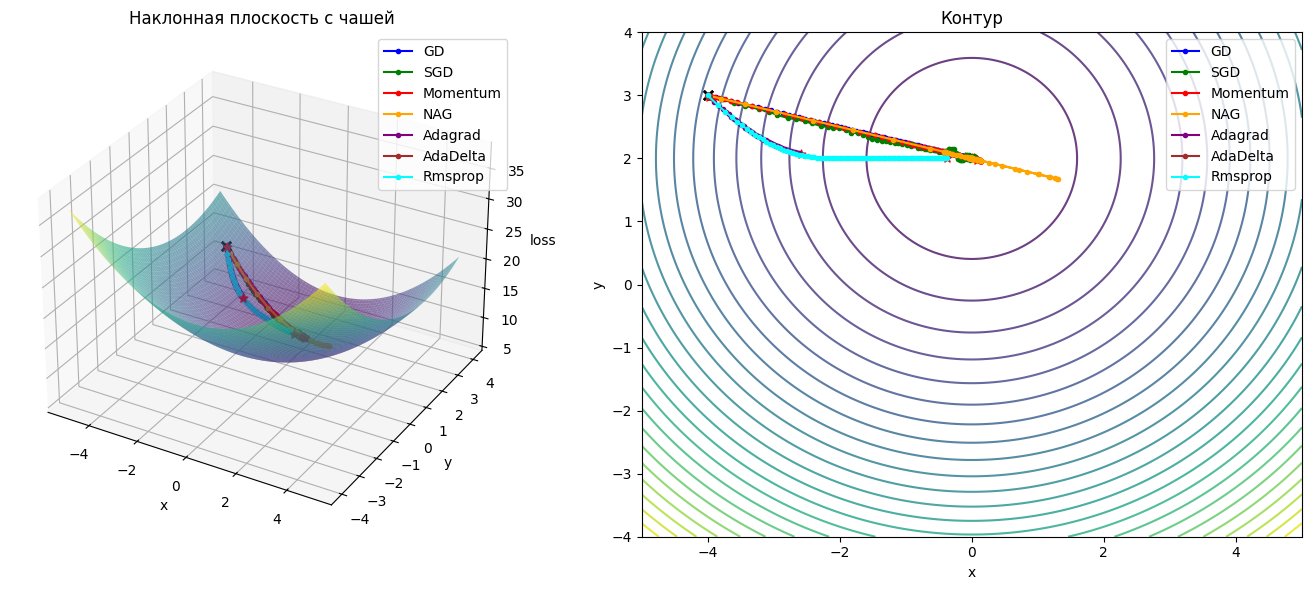


Анимации отдельных методов:


Анимация для GD готова (шагов: 120)


Анимация для SGD готова (шагов: 100)


Анимация для Momentum готова (шагов: 80)


Анимация для NAG готова (шагов: 80)


Анимация для Adagrad готова (шагов: 70)


Анимация для AdaDelta готова (шагов: 70)


Анимация для Rmsprop готова (шагов: 80)

Общая анимация готова


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. Поверхность: наклонная плоскость + чаша
# ============================================================
A, B, C = 2.0, -3.0, 6.0
eps = 0.5
x0, y0 = 2.0, -1.0

def loss(x, y):
    return A*x + B*y + C + eps * ((x - x0)**2 + (y - y0)**2)

def grad(x, y):
    gx = A + 2*eps*(x - x0)
    gy = B + 2*eps*(y - y0)
    return np.array([gx, gy])

# ============================================================
# 2. Оптимизаторы (с уменьшенным шумом для SGD)
# ============================================================
def gd(theta, lr, grad_func, **kwargs):
    return theta - lr * grad_func(theta[0], theta[1])

def sgd(theta, lr, grad_func, **kwargs):
    g = grad_func(theta[0], theta[1]) + np.random.randn(2) * 0.3  # шум поменьше
    return theta - lr * g

def momentum(theta, lr, grad_func, **kwargs):
    velocity = kwargs.get('velocity', np.zeros_like(theta))
    beta = 0.9
    g = grad_func(theta[0], theta[1])
    velocity = beta * velocity + (1 - beta) * g
    return theta - lr * velocity, velocity

def nag(theta, lr, grad_func, **kwargs):
    velocity = kwargs.get('velocity', np.zeros_like(theta))
    beta = 0.9
    theta_nesterov = theta - beta * velocity
    g = grad_func(theta_nesterov[0], theta_nesterov[1])
    velocity = beta * velocity + lr * g
    return theta - velocity, velocity

def adagrad(theta, lr, grad_func, **kwargs):
    eps_acc = 1e-8
    acc = kwargs.get('acc', np.zeros_like(theta))
    g = grad_func(theta[0], theta[1])
    acc += g**2
    return theta - lr * g / (np.sqrt(acc) + eps_acc), acc

def adadelta(theta, lr, grad_func, **kwargs):
    eps_acc = 1e-8
    acc = kwargs.get('acc', np.zeros_like(theta))
    delta_acc = kwargs.get('delta_acc', np.zeros_like(theta))
    g = grad_func(theta[0], theta[1])
    acc = 0.9 * acc + 0.1 * g**2
    delta = - np.sqrt(delta_acc + eps_acc) / np.sqrt(acc + eps_acc) * g
    delta_acc = 0.9 * delta_acc + 0.1 * delta**2
    return theta + delta, acc, delta_acc

def rmsprop(theta, lr, grad_func, **kwargs):
    eps_acc = 1e-8
    beta = 0.9
    acc = kwargs.get('acc', np.zeros_like(theta))
    g = grad_func(theta[0], theta[1])
    acc = beta * acc + (1 - beta) * g**2
    return theta - lr * g / (np.sqrt(acc) + eps_acc), acc

# ============================================================
# 3. Запуск с индивидуальными параметрами
# ============================================================
def run_optimizer(method_name, start_point, lr, n_steps):
    theta = np.array(start_point, dtype=float)
    trajectory = [theta.copy()]
    extra = {}
    for step in range(n_steps):
        if method_name == 'GD':
            theta = gd(theta, lr, grad)
        elif method_name == 'SGD':
            theta = sgd(theta, lr, grad)
        elif method_name == 'Momentum':
            theta, vel = momentum(theta, lr, grad, velocity=extra.get('velocity', np.zeros_like(theta)))
            extra['velocity'] = vel
        elif method_name == 'NAG':
            theta, vel = nag(theta, lr, grad, velocity=extra.get('velocity', np.zeros_like(theta)))
            extra['velocity'] = vel
        elif method_name == 'Adagrad':
            theta, acc = adagrad(theta, lr, grad, acc=extra.get('acc', np.zeros_like(theta)))
            extra['acc'] = acc
        elif method_name == 'AdaDelta':
            theta, acc, delta_acc = adadelta(theta, lr, grad,
                                             acc=extra.get('acc', np.zeros_like(theta)),
                                             delta_acc=extra.get('delta_acc', np.zeros_like(theta)))
            extra['acc'] = acc
            extra['delta_acc'] = delta_acc
        elif method_name == 'Rmsprop':
            theta, acc = rmsprop(theta, lr, grad, acc=extra.get('acc', np.zeros_like(theta)))
            extra['acc'] = acc
        trajectory.append(theta.copy())
    return np.array(trajectory)

# ============================================================
# 4. Настройки для каждого метода (индивидуально)
# ============================================================
start = (-4.0, 3.0)

# Словарь с параметрами: каждый метод получит свои lr и n_steps
method_configs = {
    'GD':       {'lr': 0.03, 'n_steps': 120},
    'SGD':      {'lr': 0.05, 'n_steps': 100},
    'Momentum': {'lr': 0.05, 'n_steps': 80},
    'NAG':      {'lr': 0.05, 'n_steps': 80},
    'Adagrad':  {'lr': 0.10, 'n_steps': 70},
    'AdaDelta': {'lr': 0.10, 'n_steps': 70},
    'Rmsprop':  {'lr': 0.05, 'n_steps': 80},
}

methods = list(method_configs.keys())
colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown', 'cyan']

trajectories = {}
for m in methods:
    cfg = method_configs[m]
    traj = run_optimizer(m, start, cfg['lr'], cfg['n_steps'])
    trajectories[m] = traj
    print(f"{m}: {len(traj)-1} шагов")

# Сетка для поверхности
x = np.linspace(-5, 5, 150)
y = np.linspace(-4, 4, 150)
X, Y = np.meshgrid(x, y)
Z = loss(X, Y)

# ============================================================
# 5. Статический график (без изменений)
# ============================================================
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6, edgecolor='none', rstride=2, cstride=2)
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('loss')
ax1.set_title('Наклонная плоскость с чашей')

ax2 = fig.add_subplot(122)
levels = np.linspace(Z.min(), Z.max(), 25)
ax2.contour(X, Y, Z, levels=levels, cmap='viridis', alpha=0.8)
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_title('Контур')

for m, traj in trajectories.items():
    ax1.plot(traj[:,0], traj[:,1], loss(traj[:,0], traj[:,1]),
             marker='o', markersize=3, linewidth=1.5, label=m, color=colors[methods.index(m)])
    ax2.plot(traj[:,0], traj[:,1], marker='o', markersize=3, linewidth=1.5,
             label=m, color=colors[methods.index(m)])
    ax1.scatter(traj[0,0], traj[0,1], loss(traj[0,0], traj[0,1]), color='black', s=40, marker='x')
    ax1.scatter(traj[-1,0], traj[-1,1], loss(traj[-1,0], traj[-1,1]), color='red', s=40, marker='*')
    ax2.scatter(traj[0,0], traj[0,1], color='black', s=40, marker='x')
    ax2.scatter(traj[-1,0], traj[-1,1], color='red', s=40, marker='*')

ax1.legend(); ax2.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 6. Функции анимации (адаптированы под разную длину траекторий)
# ============================================================
def animate_method(method_name, traj, X, Y, Z, loss_func):
    fig = plt.figure(figsize=(12, 5))
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122)
    
    ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.4, edgecolor='none')
    ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('loss')
    ax1.set_title(f'{method_name} – спуск по склону')
    
    ax2.contour(X, Y, Z, levels=levels, cmap='viridis', alpha=0.6)
    ax2.set_xlabel('x'); ax2.set_ylabel('y')
    ax2.set_title('Контур')
    
    point3d, = ax1.plot([], [], [], 'ro', markersize=8)
    line3d, = ax1.plot([], [], [], 'r-', alpha=0.6)
    point2d, = ax2.plot([], [], 'ro', markersize=8)
    line2d, = ax2.plot([], [], 'r-', alpha=0.6)
    
    def init():
        point3d.set_data([], []); point3d.set_3d_properties([])
        line3d.set_data([], []); line3d.set_3d_properties([])
        point2d.set_data([], []); line2d.set_data([], [])
        return point3d, line3d, point2d, line2d
    
    def animate(i):
        traj_i = traj[:i+1]
        x_vals = traj_i[:,0]; y_vals = traj_i[:,1]; z_vals = loss_func(x_vals, y_vals)
        point3d.set_data([x_vals[-1]], [y_vals[-1]]); point3d.set_3d_properties([z_vals[-1]])
        line3d.set_data(x_vals, y_vals); line3d.set_3d_properties(z_vals)
        point2d.set_data([x_vals[-1]], [y_vals[-1]])
        line2d.set_data(x_vals, y_vals)
        return point3d, line3d, point2d, line2d
    
    ani = animation.FuncAnimation(fig, animate, frames=len(traj),
                                  init_func=init, interval=120, blit=False, repeat=True)
    plt.close(fig)
    return ani

print("\nАнимации отдельных методов:")
for m in methods:
    ani = animate_method(m, trajectories[m], X, Y, Z, loss)
    display(HTML(ani.to_html5_video()))
    print(f"Анимация для {m} готова (шагов: {len(trajectories[m])-1})")

# ============================================================
# 7. Общая анимация (с учётом разной длины траекторий)
# ============================================================
def animate_all_methods(trajectories, X, Y, Z, loss_func, methods, colors):
    fig = plt.figure(figsize=(14, 6))
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122)
    
    ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.3, edgecolor='none')
    ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('loss')
    ax1.set_title('Все методы – спуск по склону')
    
    ax2.contour(X, Y, Z, levels=levels, cmap='viridis', alpha=0.5)
    ax2.set_xlabel('x'); ax2.set_ylabel('y')
    ax2.set_title('Контур – все методы')
    
    lines3d, points3d, lines2d, points2d = [], [], [], []
    for m, col in zip(methods, colors):
        l3, = ax1.plot([], [], [], color=col, linestyle='-', alpha=0.7, label=m)
        p3, = ax1.plot([], [], [], 'o', color=col, markersize=6)
        l2, = ax2.plot([], [], color=col, linestyle='-', alpha=0.7)
        p2, = ax2.plot([], [], 'o', color=col, markersize=6)
        lines3d.append(l3); points3d.append(p3)
        lines2d.append(l2); points2d.append(p2)
    ax1.legend(); ax2.legend()
    
    max_steps = max([len(traj) for traj in trajectories.values()])
    
    def init():
        for l3,p3,l2,p2 in zip(lines3d, points3d, lines2d, points2d):
            l3.set_data([], []); l3.set_3d_properties([])
            p3.set_data([], []); p3.set_3d_properties([])
            l2.set_data([], []); p2.set_data([], [])
        return lines3d + points3d + lines2d + points2d
    
    def animate(i):
        for idx, m in enumerate(methods):
            traj = trajectories[m]
            if i >= len(traj):
                traj_i = traj
            else:
                traj_i = traj[:i+1]
            x_vals = traj_i[:,0]; y_vals = traj_i[:,1]; z_vals = loss_func(x_vals, y_vals)
            lines3d[idx].set_data(x_vals, y_vals); lines3d[idx].set_3d_properties(z_vals)
            points3d[idx].set_data([x_vals[-1]], [y_vals[-1]]); points3d[idx].set_3d_properties([z_vals[-1]])
            lines2d[idx].set_data(x_vals, y_vals)
            points2d[idx].set_data([x_vals[-1]], [y_vals[-1]])
        return lines3d + points3d + lines2d + points2d
    
    ani_all = animation.FuncAnimation(fig, animate, frames=max_steps,
                                      init_func=init, interval=120, blit=False, repeat=True)
    plt.close(fig)
    return ani_all

ani_combined = animate_all_methods(trajectories, X, Y, Z, loss, methods, colors)
print("\nОбщая анимация готова")
display(HTML(ani_combined.to_html5_video()))